# 01 — Découverte du dataset

## Objectif

Ce notebook présente une première exploration du dataset  
« Diabetes 130-US Hospitals for Years 1999–2008 ».

Les objectifs sont :

- charger le dataset ;
- vérifier sa structure ;
- identifier les colonnes ;
- analyser les types de données ;
- étudier les principales statistiques ;
- comprendre la variable cible `readmitted` ;
- préparer les futures étapes de qualité et de transformation.

In [1]:
from pathlib import Path

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "source" / "diabetic_data.csv"
MAPPING_PATH = PROJECT_ROOT / "data" / "source" / "IDS_mapping.csv"

print(f"Dataset principal : {DATA_PATH}")
print(f"Fichier de mapping : {MAPPING_PATH}")

Dataset principal : c:\Users\pc\chu-oujda-rehospitalisation-risk\data\source\diabetic_data.csv
Fichier de mapping : c:\Users\pc\chu-oujda-rehospitalisation-risk\data\source\IDS_mapping.csv


In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "source" / "diabetic_data.csv"
MAPPING_PATH = PROJECT_ROOT / "data" / "source" / "IDS_mapping.csv"

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Le fichier diabetic_data.csv est introuvable : {DATA_PATH}"
    )

print("Le fichier principal existe.")

Le fichier principal existe.


In [5]:
if MAPPING_PATH.exists():
    print("Le fichier IDS_mapping.csv existe.")
else:
    print("Le fichier IDS_mapping.csv n'a pas encore été ajouté.")

Le fichier IDS_mapping.csv existe.


In [6]:
df = pl.read_csv(
    DATA_PATH,
    null_values=["?", "Unknown/Invalid", "NULL", "None", ""],
    infer_schema_length=10000,
)

df.head()

encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
i64,i64,str,str,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2278392,8222157,"""Caucasian""","""Female""","""[0-10)""",null,6,25,1,1,null,"""Pediatrics-Endocrinology""",41,0,1,0,0,0,"""250.83""",null,null,1,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO"""
149190,55629189,"""Caucasian""","""Female""","""[10-20)""",null,1,1,7,3,null,null,59,0,18,0,0,0,"""276""","""250.01""","""255""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""",""">30"""
64410,86047875,"""AfricanAmerican""","""Female""","""[20-30)""",null,1,1,7,2,null,null,11,5,13,2,0,1,"""648""","""250""","""V27""",6,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""NO"""
500364,82442376,"""Caucasian""","""Male""","""[30-40)""",null,1,1,7,2,null,null,44,1,16,0,0,0,"""8""","""250.43""","""403""",7,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
16680,42519267,"""Caucasian""","""Male""","""[40-50)""",null,1,1,7,1,null,null,51,0,8,0,0,0,"""197""","""157""","""250""",5,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""


In [7]:
null_values=["?", "Unknown/Invalid", "NULL", "None", ""]

In [8]:
df_raw = pl.read_csv(
    DATA_PATH,
    infer_schema_length=10000,
)

In [9]:
row_count = df.height
column_count = df.width

print(f"Nombre de lignes : {row_count:,}")
print(f"Nombre de colonnes : {column_count}")

Nombre de lignes : 101,766
Nombre de colonnes : 50


In [10]:
df.shape

(101766, 50)

In [11]:
df.head(10)

encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
i64,i64,str,str,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2278392,8222157,"""Caucasian""","""Female""","""[0-10)""",null,6,25,1,1,null,"""Pediatrics-Endocrinology""",41,0,1,0,0,0,"""250.83""",null,null,1,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO"""
149190,55629189,"""Caucasian""","""Female""","""[10-20)""",null,1,1,7,3,null,null,59,0,18,0,0,0,"""276""","""250.01""","""255""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""",""">30"""
64410,86047875,"""AfricanAmerican""","""Female""","""[20-30)""",null,1,1,7,2,null,null,11,5,13,2,0,1,"""648""","""250""","""V27""",6,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""NO"""
500364,82442376,"""Caucasian""","""Male""","""[30-40)""",null,1,1,7,2,null,null,44,1,16,0,0,0,"""8""","""250.43""","""403""",7,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
16680,42519267,"""Caucasian""","""Male""","""[40-50)""",null,1,1,7,1,null,null,51,0,8,0,0,0,"""197""","""157""","""250""",5,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
35754,82637451,"""Caucasian""","""Male""","""[50-60)""",null,2,1,2,3,null,null,31,6,16,0,0,0,"""414""","""411""","""250""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",""">30"""
55842,84259809,"""Caucasian""","""Male""","""[60-70)""",null,3,1,2,4,null,null,70,1,21,0,0,0,"""414""","""411""","""V45""",7,null,null,"""Steady""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
63768,114882984,"""Caucasian""","""Male""","""[70-80)""",null,1,1,7,5,null,null,73,0,12,0,0,0,"""428""","""492""","""250""",8,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""",""">30"""
12522,48330783,"""Caucasian""","""Female""","""[80-90)""",null,2,1,4,13,null,null,68,2,28,0,0,0,"""398

In [12]:
df.tail(5)

encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
i64,i64,str,str,str,str,i64,i64,i64,i64,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
443847548,100162476,"""AfricanAmerican""","""Male""","""[70-80)""",null,1,3,7,3,"""MC""",null,51,0,16,0,0,0,"""250.13""","""291""","""458""",9,null,""">8""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Down""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""",""">30"""
443847782,74694222,"""AfricanAmerican""","""Female""","""[80-90)""",null,1,4,5,5,"""MC""",null,33,3,18,0,0,1,"""560""","""276""","""787""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""Yes""","""NO"""
443854148,41088789,"""Caucasian""","""Male""","""[70-80)""",null,1,1,7,1,"""MC""",null,53,0,9,1,0,0,"""38""","""590""","""296""",13,null,null,"""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Down""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
443857166,31693671,"""Caucasian""","""Female""","""[80-90)""",null,2,3,7,10,"""MC""","""Surgery-General""",45,2,21,0,0,1,"""996""","""285""","""998""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""Steady""","""No""","""No""","""Steady""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""Up""","""No""","""No""","""No""","""No""","""No""","""Ch""","""Yes""","""NO"""
443867222,175429310,"""Caucasian""","""Male""","""[70-80)""",null,1,1,7,6,null,null,13,3,3,0,0,0,"""530""","""530""","""787""",9,null,null,"""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""No""","""NO"""


In [13]:
for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


In [14]:
schema_df = pl.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
    }
)

schema_df

column,dtype
str,str
"""encounter_id""","""Int64"""
"""patient_nbr""","""Int64"""
"""race""","""String"""
"""gender""","""String"""
"""age""","""String"""
…,…
"""metformin-rosiglitazone""","""String"""
"""metformin-pioglitazone""","""String"""
"""change""","""String"""


In [15]:
df.schema

Schema([('encounter_id', Int64),
        ('patient_nbr', Int64),
        ('race', String),
        ('gender', String),
        ('age', String),
        ('weight', String),
        ('admission_type_id', Int64),
        ('discharge_disposition_id', Int64),
        ('admission_source_id', Int64),
        ('time_in_hospital', Int64),
        ('payer_code', String),
        ('medical_specialty', String),
        ('num_lab_procedures', Int64),
        ('num_procedures', Int64),
        ('num_medications', Int64),
        ('number_outpatient', Int64),
        ('number_emergency', Int64),
        ('number_inpatient', Int64),
        ('diag_1', String),
        ('diag_2', String),
        ('diag_3', String),
        ('number_diagnoses', Int64),
        ('max_glu_serum', String),
        ('A1Cresult', String),
        ('metformin', String),
        ('repaglinide', String),
        ('nateglinide', String),
        ('chlorpropamide', String),
        ('glimepiride', String),
        ('acetohexamid

In [16]:
numeric_columns = [
    column
    for column, dtype in df.schema.items()
    if dtype.is_numeric()
]

categorical_columns = [
    column
    for column, dtype in df.schema.items()
    if dtype == pl.String
]

print("Colonnes numériques :")
print(numeric_columns)

print("\nColonnes textuelles :")
print(categorical_columns)

Colonnes numériques :
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Colonnes textuelles :
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [17]:
identifier_columns = [
    "encounter_id",
    "patient_nbr",
]

coded_categorical_columns = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
]

target_column = "readmitted"

In [18]:
df.describe()

statistic,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
str,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",101766.0,101766.0,"""99493""","""101763""","""101766""","""3197""",101766.0,101766.0,101766.0,101766.0,"""61510""","""51817""",101766.0,101766.0,101766.0,101766.0,101766.0,101766.0,"""101745""","""101408""","""100343""",101766.0,"""5346""","""17018""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766""","""101766"""
"""null_count""",0.0,0.0,"""2273""","""3""","""0""","""98569""",0.0,0.0,0.0,0.0,"""40256""","""49949""",0.0,0.0,0.0,0.0,0.0,0.0,"""21""","""358""","""1423""",0.0,"""96420""","""84748""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",1.6520e8,5.4330e7,null,null,null,null,2.024006,3.715642,5.754437,4.395987,null,null,43.095641,1.33973,16.021844,0.369357,0.197836,0.635566,null,null,null,7.422607,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",1.0264e8,3.8696e7,null,null,null,null,1.445403,5.280166,4.064081,2.985108,null,null,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,null,null,null,1.9336,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",12522.0,135.0,"""AfricanAmerican""","""Female""","""[0-10)""",""">200""",1.0,1.0,1.0,1.0,"""BC""","""AllergyandImmunology""",1.0,0.0,1.0,0.0,0.0,0.0,"""10""","""11""","""11""",1.0,""">200""",""">7""","""Down""","""Down""","""Down""","""Down""","""Down""","""No""","""Down""","""Down""","""No""","""Down""","""Down""","""Down""","""Down""","""No""","""No""","""No""","""No""","""Down""","""Down""","""No""","""No""","""No""","""No""","""Ch""","""No""","""<30"""
"""25%""",8.4960072e7,2.3413212e7,null,null,null,null,1.0,1.0,1.0,2.0,null,null,31.0,0.0,10.0,0.0,0.0,0.0,null,null,null,6.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",1.5238968e8,4.5505143e7,null,null,null,null,1.0,1.0,7.0,4.0,null,null,44.0,1.0,15.0,0.0,0.0,0.0,null,null,null,8.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",2.30271972e8,8.7546186e7,null,null,null,null,3.0,4.0,7.0,6.0,null,null,57.0,2.0,20.0,0.0,0.0,1.0,null,null,null,9.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",4.43867222e8,1.89502619e8,"""Other""","""Male""","""[90-100)""","""[75-100)""",8.0,28.0,25.0,14.0,"""WC""","""Urology""",132.0,6.0,81.0,42.0,76.0,21.0,"""V71""","""V86""","""V86""",16.0,"""Norm""","""Norm""","""Up""","""U

In [19]:
df.select(
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "number_diagnoses",
    ]
).describe()

statistic,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",101766.0,101766.0,101766.0,101766.0,101766.0,101766.0,101766.0,101766.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.395987,43.095641,1.33973,16.021844,0.369357,0.197836,0.635566,7.422607
"""std""",2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.9336
"""min""",1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
"""25%""",2.0,31.0,0.0,10.0,0.0,0.0,0.0,6.0
"""50%""",4.0,44.0,1.0,15.0,0.0,0.0,0.0,8.0
"""75%""",6.0,57.0,2.0,20.0,0.0,0.0,1.0,9.0
"""max""",14.0,132.0,6.0,81.0,42.0,76.0,21.0,16.0


In [20]:
df.select(
    pl.col("readmitted").value_counts(sort=True)
)

readmitted
struct[2]
"{""NO"",54864}"
"{"">30"",35545}"
"{""<30"",11357}"


In [21]:
df.select(
    pl.col("age").value_counts(sort=True)
)

age
struct[2]
"{""[70-80)"",26068}"
"{""[60-70)"",22483}"
"{""[50-60)"",17256}"
"{""[80-90)"",17197}"
"{""[40-50)"",9685}"
"{""[30-40)"",3775}"
"{""[90-100)"",2793}"
"{""[20-30)"",1657}"
"{""[10-20)"",691}"


In [22]:
df.select(
    pl.col("gender").value_counts(sort=True)
)

gender
struct[2]
"{""Female"",54708}"
"{""Male"",47055}"
"{null,3}"


In [23]:
unique_counts = pl.DataFrame(
    {
        "column": df.columns,
        "unique_count": [
            df.select(pl.col(column).n_unique()).item()
            for column in df.columns
        ],
    }
).sort("unique_count")

unique_counts

column,unique_count
str,i64
"""examide""",1
"""citoglipton""",1
"""acetohexamide""",2
"""tolbutamide""",2
"""troglitazone""",2
…,…
"""diag_1""",717
"""diag_2""",749
"""diag_3""",790


In [24]:
constant_columns = unique_counts.filter(
    pl.col("unique_count") <= 1
)

constant_columns

column,unique_count
str,i64
"""examide""",1
"""citoglipton""",1


In [25]:
target_distribution = (
    df.group_by("readmitted")
    .agg(pl.len().alias("count"))
    .with_columns(
        (
            pl.col("count") / pl.col("count").sum() * 100
        ).round(2).alias("percentage")
    )
    .sort("count", descending=True)
)

target_distribution

readmitted,count,percentage
str,u32,f64
"""NO""",54864,53.91
""">30""",35545,34.93
"""<30""",11357,11.16


In [26]:
df_target_preview = df.with_columns(
    pl.when(pl.col("readmitted") == "<30")
    .then(1)
    .otherwise(0)
    .alias("readmitted_30_days")
)

df_target_preview.select(
    pl.col("readmitted_30_days").value_counts(sort=True)
)

readmitted_30_days
struct[2]
"{0,90409}"
"{1,11357}"


In [27]:
df_target_preview.group_by("readmitted_30_days").agg(
    pl.len().alias("count")
).with_columns(
    (
        pl.col("count") / pl.col("count").sum() * 100
    ).round(2).alias("percentage")
)

readmitted_30_days,count,percentage
i32,u32,f64
1,11357,11.16
0,90409,88.84


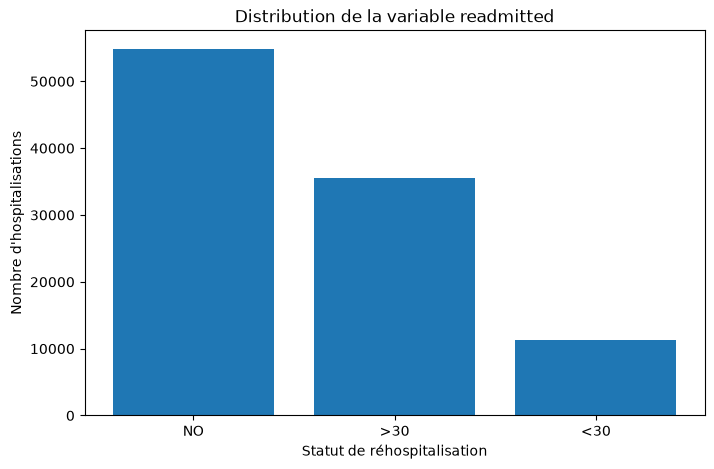

In [28]:
target_pd = target_distribution.to_pandas()

plt.figure(figsize=(8, 5))
plt.bar(target_pd["readmitted"], target_pd["count"])
plt.title("Distribution de la variable readmitted")
plt.xlabel("Statut de réhospitalisation")
plt.ylabel("Nombre d'hospitalisations")
plt.show()

In [29]:
unique_encounters = df.select(
    pl.col("encounter_id").n_unique()
).item()

print(unique_encounters)

101766


In [30]:
print(f"Lignes : {df.height}")
print(f"Encounter IDs uniques : {unique_encounters}")

Lignes : 101766
Encounter IDs uniques : 101766


In [31]:
print(f"Lignes : {df.height}")
print(f"Encounter IDs uniques : {unique_encounters}")

Lignes : 101766
Encounter IDs uniques : 101766


In [32]:
print(f"Lignes : {df.height}")
print(f"Encounter IDs uniques : {unique_encounters}")

Lignes : 101766
Encounter IDs uniques : 101766


In [33]:
unique_patients = df.select(
    pl.col("patient_nbr").n_unique()
).item()

print(f"Nombre de patients uniques : {unique_patients:,}")

Nombre de patients uniques : 71,518


In [34]:
average_encounters_per_patient = df.height / unique_patients

print(
    f"Nombre moyen de séjours par patient : "
    f"{average_encounters_per_patient:.2f}"
)

Nombre moyen de séjours par patient : 1.42


In [35]:
patient_encounters = (
    df.group_by("patient_nbr")
    .agg(pl.len().alias("encounter_count"))
    .sort("encounter_count", descending=True)
)

patient_encounters.head(20)

patient_nbr,encounter_count
i64,u32
88785891,40
43140906,28
1660293,23
23199021,23
88227540,23
…,…
97391007,19
88479036,19
91751121,18


In [36]:
patients_multiple_encounters = patient_encounters.filter(
    pl.col("encounter_count") > 1
).height

print(
    f"Patients avec plusieurs séjours : "
    f"{patients_multiple_encounters:,}"
)

Patients avec plusieurs séjours : 16,773


In [37]:
main_numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

In [38]:
df.select(main_numeric_columns).describe()

statistic,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",101766.0,101766.0,101766.0,101766.0,101766.0,101766.0,101766.0,101766.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.395987,43.095641,1.33973,16.021844,0.369357,0.197836,0.635566,7.422607
"""std""",2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.9336
"""min""",1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
"""25%""",2.0,31.0,0.0,10.0,0.0,0.0,0.0,6.0
"""50%""",4.0,44.0,1.0,15.0,0.0,0.0,0.0,8.0
"""75%""",6.0,57.0,2.0,20.0,0.0,0.0,1.0,9.0
"""max""",14.0,132.0,6.0,81.0,42.0,76.0,21.0,16.0


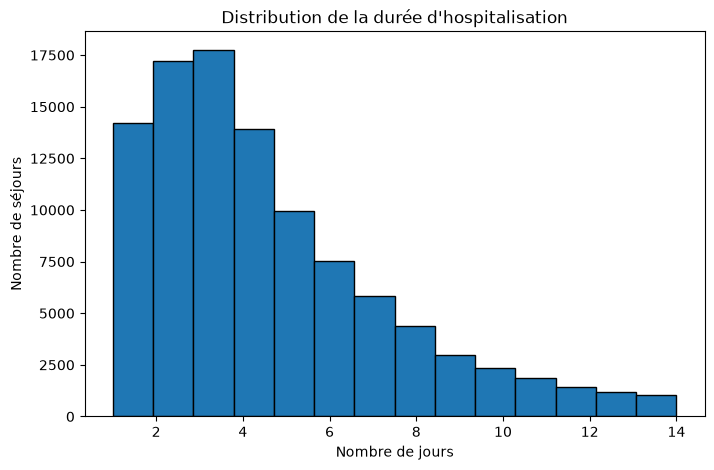

In [39]:
time_in_hospital_pd = df.select(
    "time_in_hospital"
).to_pandas()

plt.figure(figsize=(8, 5))
plt.hist(
    time_in_hospital_pd["time_in_hospital"],
    bins=14,
    edgecolor="black",
)
plt.title("Distribution de la durée d'hospitalisation")
plt.xlabel("Nombre de jours")
plt.ylabel("Nombre de séjours")
plt.show()

In [40]:
def categorical_summary(
    dataframe: pl.DataFrame,
    column: str,
    limit: int = 20,
) -> pl.DataFrame:
    return (
        dataframe.group_by(column)
        .agg(pl.len().alias("count"))
        .with_columns(
            (
                pl.col("count") / pl.col("count").sum() * 100
            ).round(2).alias("percentage")
        )
        .sort("count", descending=True)
        .head(limit)
    )

In [41]:
categorical_summary(df, "race")

race,count,percentage
str,u32,f64
"""Caucasian""",76099,74.78
"""AfricanAmerican""",19210,18.88
null,2273,2.23
"""Hispanic""",2037,2.0
"""Other""",1506,1.48
"""Asian""",641,0.63


In [42]:
categorical_summary(df, "gender")

gender,count,percentage
str,u32,f64
"""Female""",54708,53.76
"""Male""",47055,46.24
null,3,0.0


In [43]:
categorical_summary(df, "age")

age,count,percentage
str,u32,f64
"""[70-80)""",26068,25.62
"""[60-70)""",22483,22.09
"""[50-60)""",17256,16.96
"""[80-90)""",17197,16.9
"""[40-50)""",9685,9.52
"""[30-40)""",3775,3.71
"""[90-100)""",2793,2.74
"""[20-30)""",1657,1.63
"""[10-20)""",691,0.68


In [44]:
categorical_summary(df, "medical_specialty")

medical_specialty,count,percentage
str,u32,f64
null,49949,49.08
"""InternalMedicine""",14635,14.38
"""Emergency/Trauma""",7565,7.43
"""Family/GeneralPractice""",7440,7.31
"""Cardiology""",5352,5.26
…,…,…
"""Gastroenterology""",564,0.55
"""Surgery-Vascular""",533,0.52
"""Surgery-Neuro""",468,0.46


In [45]:
categorical_summary(df, "A1Cresult")

A1Cresult,count,percentage
str,u32,f64
null,84748,83.28
""">8""",8216,8.07
"""Norm""",4990,4.9
""">7""",3812,3.75


In [46]:
categorical_summary(df, "max_glu_serum")

max_glu_serum,count,percentage
str,u32,f64
null,96420,94.75
"""Norm""",2597,2.55
""">200""",1485,1.46
""">300""",1264,1.24


In [47]:
categorical_summary(df, "insulin")

insulin,count,percentage
str,u32,f64
"""No""",47383,46.56
"""Steady""",30849,30.31
"""Down""",12218,12.01
"""Up""",11316,11.12


In [48]:
categorical_summary(df, "change")

change,count,percentage
str,u32,f64
"""No""",54755,53.8
"""Ch""",47011,46.2


In [49]:
categorical_summary(df, "diabetesMed")

diabetesMed,count,percentage
str,u32,f64
"""Yes""",78363,77.0
"""No""",23403,23.0


In [50]:
df.select(
    ["diag_1", "diag_2", "diag_3"]
).head(20)

diag_1,diag_2,diag_3
str,str,str
"""250.83""",null,null
"""276""","""250.01""","""255"""
"""648""","""250""","""V27"""
"""8""","""250.43""","""403"""
"""197""","""157""","""250"""
…,…,…
"""999""","""507""","""996"""
"""410""","""411""","""414"""
"""682""","""174""","""250"""


In [51]:
df.select(
    [
        pl.col("diag_1").n_unique().alias("diag_1_unique"),
        pl.col("diag_2").n_unique().alias("diag_2_unique"),
        pl.col("diag_3").n_unique().alias("diag_3_unique"),
    ]
)

diag_1_unique,diag_2_unique,diag_3_unique
u32,u32,u32
717,749,790


In [52]:
categorical_summary(df, "diag_1", limit=20)

diag_1,count,percentage
str,u32,f64
"""428""",6862,6.74
"""414""",6581,6.47
"""786""",4016,3.95
"""410""",3614,3.55
"""486""",3508,3.45
…,…,…
"""599""",1595,1.57
"""584""",1520,1.49
"""V57""",1207,1.19


In [53]:
medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

In [54]:
existing_medication_columns = [
    column
    for column in medication_columns
    if column in df.columns
]

missing_medication_columns = [
    column
    for column in medication_columns
    if column not in df.columns
]

print("Colonnes disponibles :", existing_medication_columns)
print("Colonnes absentes :", missing_medication_columns)

Colonnes disponibles : ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Colonnes absentes : []


In [55]:
categorical_summary(df, "metformin")

metformin,count,percentage
str,u32,f64
"""No""",81778,80.36
"""Steady""",18346,18.03
"""Up""",1067,1.05
"""Down""",575,0.57


In [56]:
categorical_summary(df, "insulin")

insulin,count,percentage
str,u32,f64
"""No""",47383,46.56
"""Steady""",30849,30.31
"""Down""",12218,12.01
"""Up""",11316,11.12


# Conclusion

L’exploration initiale montre que le dataset représente des
hospitalisations de patients diabétiques.

Les principales observations sont :

- une ligne représente une hospitalisation ;
- un patient peut avoir plusieurs hospitalisations ;
- la variable cible est `readmitted` ;
- la classe `<30` représente la réhospitalisation précoce ;
- plusieurs colonnes sont catégorielles ;
- certains codes nécessitent un enrichissement ;
- les diagnostics devront être regroupés ;
- les données contiennent des valeurs manquantes représentées
  de différentes manières ;
- certaines variables sont fortement incomplètes ;
- les prochaines étapes devront mettre en place des règles
  de validation et de nettoyage reproductibles.